# **Neural Networks and Differential Equations: From Infinite Layers to Continuous Modelling**

## **Part I: Differential Equations Basics**

### **Tutorial @ IJCAI 2026**

#### **Cecília Coelho, Luís Ferrás and Andrzej Dulny**

#### **Go to [website][Website]**

[Website]: https://ceciliacoelho.github.io/tutorialNN4DEs


# --------------------------------------------------------

# Differential Equations Basics (Part I)

#### Numerical solution of a simple ODE using the explicit Euler method


The differential equation $\dfrac{df(t)}{dt}=e^{−t}$ with initial condition $f(0)=−1$ has the exact solution $f(t)=−e^{−t}$. Approximate the solution to this initial value problem between 0 and 1 in increments of 0.1 using the **Explicit Euler Formula**. Plot the difference between the approximated solution and the exact solution.



Play with the **solver**, **model parameters** and the **number of mesh elements**.

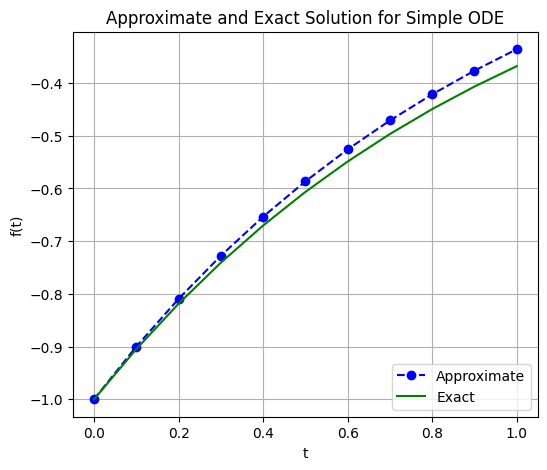

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#plt.style.use('seaborn-poster')
%matplotlib inline

# Define parameters
f = lambda t, s: np.exp(-t) # ODE
h = 0.1 # Step size
t = np.arange(0, 1 + h, h) # Numerical grid
s0 = -1 # Initial Condition

# Explicit Euler Method
s = np.zeros(len(t))
s[0] = s0

for i in range(0, len(t) - 1):
    s[i + 1] = s[i] + h*f(t[i], s[i])

plt.figure(figsize = (6, 5))
plt.plot(t, s, 'bo--', label='Approximate')
plt.plot(t, -np.exp(-t), 'g', label='Exact')
plt.title('Approximate and Exact Solution \
for Simple ODE')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.grid()
plt.legend(loc='lower right')
plt.show()

## Differential Equations Basics (Part II)

#### Logistic Growth of a Population of Organisms

Consider a population of organisms that follows a logistic growth. The population size $P(t)$ at time $t$ is governed by the following differential equation:
            \begin{equation}
             P'(t) = r P(t) \left(1 - \frac{P(t)}{K}\right), \quad P(t_0) = 100,
            \end{equation}
            where $r$ is the growth rate, and $K$ is the carrying capacity of the environment. Consider $r=0.1, K=1000$. Also, consider a mesh of 200 points.



Play with the **solver**, **model parameters** and the **number of mesh elements**.

##### First, try to implement $P'(t) = r P(t)$

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

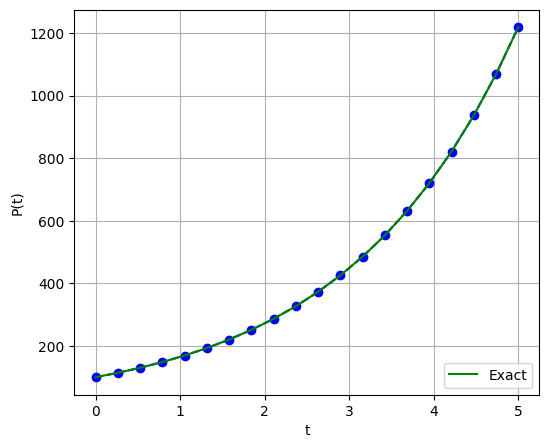

In [ ]:
r = 0.5
y0 = [100]
t = np.linspace(0, 5, 20)

def ODE(t, y):
    return r * y

sol = solve_ivp(ODE, [0, 5], y0, t_eval=t)

plt.figure(figsize = (6, 5))
plt.plot(sol.t.T, sol.y.T,'bo--')
plt.plot(t, y0*np.exp(r*t), 'g', label='Exact')
plt.xlabel('t')
plt.ylabel('P(t)')
plt.grid()
plt.legend(loc='lower right')
plt.show()

##### Now try to implement $P'(t) = r P(t) \left(1 - \frac{P(t)}{K}\right)$

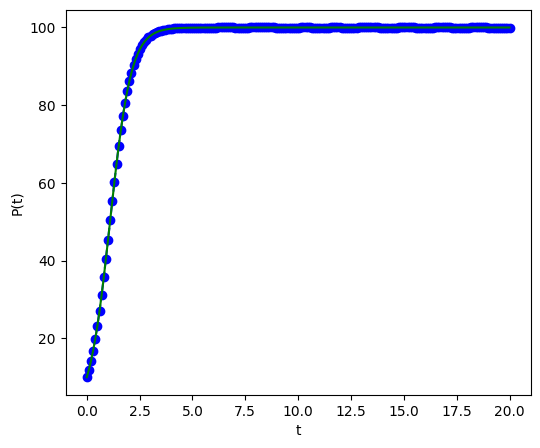

In [ ]:
r = 2
K = 100
y0 = 10
t = np.linspace(0, 20, 200)

def ODE(t, y):
    return r * y * (1- y/K)

sol = solve_ivp(ODE, [0, 20], [y0], t_eval=t)

plt.figure(figsize = (6, 5))
plt.plot(sol.t.T, sol.y.T,'bo--')
plt.plot(t, (K*y0*np.exp(r*t))/(K+y0*(np.exp(r*t)-1)), 'g', label='Exact')
plt.xlabel('t')
plt.ylabel('P(t)')
plt.show()